In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import seaborn as sns

In [ ]:
ds_info = pd.read_csv('../data/dataset_info.csv')
sample_info = pd.read_csv('../data/sample_info.csv')
ts_info = pd.read_csv('../data/timeseries_info.csv')
dim_length = pd.read_csv('../data/dim_length.csv')

In [4]:
ds_info['dataset_name'].unique()

array(['housing', 'electricity', 'bike_sharing', 'energy', 'bitcoin',
       'air_quality', 'etth', 'household_power_consumption',
       'stackoverflow', 'covid', 'weather', 'covid_mobility', 'illness',
       'madrid19', 'madrid22', 'rideshare', 'electricity_price', 'wind',
       'auser', 'doganella', 'luco', 'petrignano', 'bilancino', 'arno',
       'amiata', 'lupa', 'm5_other', 'm5_id', 'demo'], dtype=object)

In [6]:
ts_info.columns

Index(['ts_id', 'dataset_name', 'target_name', 'ts_name', 'alpha', 'arch_acf',
       'arch_lm', 'arch_r2', 'beta', 'crossing_points', 'curvature',
       'diff1_acf1', 'diff1_acf10', 'diff1x_pacf5', 'diff2_acf1',
       'diff2_acf10', 'diff2x_pacf5', 'e_acf1', 'e_acf10', 'entropy',
       'flat_spots', 'garch_acf', 'garch_r2', 'hurst', 'hw_alpha', 'hw_beta',
       'hw_gamma', 'linearity', 'lumpiness', 'nonlinearity', 'nperiods',
       'peak', 'seas_acf1', 'seas_pacf', 'seasonal_period',
       'seasonal_strength', 'series_length', 'spike', 'stability', 'trend',
       'trough', 'unitroot_kpss', 'unitroot_pp', 'x_acf1', 'x_acf10',
       'x_pacf5'],
      dtype='object')

In [7]:
drop_cols = ['ts_id', 'dataste', 'ts_name', 'ts_type', 'ts_unit', 'ts_description']
numeric_cols = ts_info.select_dtypes(include=[np.number])
numeric_cols = numeric_cols.drop(columns=['ts_id', 'arch_acf', 'arch_r2', 'garch_acf', 'garch_r2', 'spike', 'nperiods'])

In [11]:
sample_info['ts_ids'] = sample_info['ts_ids'].apply(
    lambda x: ast.literal_eval("[" + x + "]") if not x.strip().startswith('[') else ast.literal_eval(x)
)

In [12]:
dataset_names = sample_info['dataset_name'].unique()
ts_ids = sample_info['ts_ids'].explode().unique()

In [13]:
len(dataset_names), len(ts_ids), len(sample_info)

(20, 117, 387)

In [14]:
ds_info = ds_info[ds_info['dataset_name'].isin(dataset_names)]
ds_info['domain'].value_counts()

domain
nature      7
energy      6
human       3
economic    2
demand      2
Name: count, dtype: int64

In [15]:
ts_info = ts_info[ts_info['ts_id'].isin(ts_ids)]
ts_info['dataset_name'].value_counts()

dataset_name
air_quality                    32
m5_other                       27
m5_id                          14
madrid22                        5
auser                           5
rideshare                       5
madrid19                        5
amiata                          4
illness                         3
household_power_consumption     2
weather                         2
electricity                     2
etth                            2
energy                          2
housing                         2
bitcoin                         1
electricity_price               1
wind                            1
bilancino                       1
bike_sharing                    1
Name: count, dtype: int64

In [16]:
ds_info

,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
0,housing,economic,QS-OCT,74,1,['_single_series_'],"['CSUSHPISA', 'MSPUS']",2,"['EVACANTUSQ176N', 'GDP', 'INTDSRUSM193N', 'MO...",8,[],0,[],0
1,electricity,energy,D,2106,1,['_single_series_'],"['RRP', 'demand']",2,"['RRP_negative', 'RRP_positive', 'demand_neg_R...",9,"['school_day', 'holiday']",2,"['school_day', 'holiday']",2
2,bike_sharing,human,h,8760,1,['_single_series_'],['Rented Bike Count'],1,"['Dew point temperature(°C)', 'Humidity(%)', '...",8,"['Seasons', 'Holiday', 'Functioning Day']",3,"['Seasons', 'Holiday', 'Functioning Day']",3
3,energy,energy,h,30233,1,['_single_series_'],"['price_actual', 'total_load_actual']",2,"['generation_biomass', 'generation_fossil_brow...",20,"['price_day_ahead', 'total_load_forecast', 'fo...",4,[],0
4,bitcoin,economic,D,2659,1,['_single_series_'],['price'],1,"['active_addresses', 'av_transaction_value', '...",17,[],0,[],0
5,air_quality,nature,h,10898,35,"['aotizhongxin_aq', 'badaling_aq', 'beibuxinqu...","['CO', 'NO2', 'O3', 'SO2']",4,"['PM10', 'PM2.5']",2,[],0,[],0
6,etth,energy,h,17420,2,"['one', 'two']",['OT'],1,"['HUFL', 'HULL', 'LUFL', 'LULL', 'MUFL', 'MULL']",6,[],0,[],0
7,household_power_consumption,energy,h,16758,1,['_single_series_'],"['Global_active_power', 'Global_reactive_power']",2,"['Global_intensity', 'Sub_metering_1', 'Sub_me...",5,[],0,[],0
10,weather,nature,h,100057,1,['_single_series_'],"['surface_solar_radiation', 'wind_speed']",2,"['dewpoint_temperature', 'mean_sea_level_press...",6,[],0,[],0
12,illness,human,W-TUE,966,1,['_single_series_'],"['AGE 0-4', 'AGE 5-24', 'ILITOTAL']",3,"['% WEIGHTED ILI', '%UNWEIGHTED ILI', 'NUM. OF...",4,[],0,[],0


In [17]:
ts_info

,ts_id,dataset_name,target_name,ts_name,alpha,arch_acf,arch_lm,arch_r2,beta,crossing_points,...,series_length,spike,stability,trend,trough,unitroot_kpss,unitroot_pp,x_acf1,x_acf10,x_pacf5
0,0,housing,CSUSHPISA,_single_series_,1.000000,NaN,0.993639,NaN,1.000000e+00,3,...,74,2.685359e-10,0.830683,0.999390,3,1.067865,1.955101,0.916751,3.904710,0.842354
1,1,housing,MSPUS,_single_series_,0.533253,NaN,0.901407,NaN,5.332530e-01,3,...,74,1.691534e-08,0.892244,0.993871,3,1.733095,0.681211,0.923379,5.103433,0.862784
2,2,electricity,RRP,_single_series_,0.033552,NaN,0.002037,NaN,1.895769e-12,221,...,2106,4.059679e-05,0.264956,0.353688,4,2.783658,-1672.912986,0.281631,0.131347,0.083994
3,3,electricity,demand,_single_series_,1.000000,NaN,0.231181,NaN,6.665830e-14,477,...,2106,4.774806e-08,0.458714,0.732723,4,1.968673,-670.880592,0.678881,1.499133,0.613767
4,4,bike_sharing,Rented Bike Count,_single_series_,1.000000,NaN,0.553017,NaN,6.190865e-10,773,...,8760,1.639069e-09,0.439178,0.767270,5,18.969179,-848.620781,0.903427,2.547053,0.916440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1319,1319,m5_id,sales,FOODS_3_628_TX_3_evaluation,0.070661,NaN,0.004861,NaN,6.490409e-16,752,...,1941,7.996374e-07,0.253688,0.393679,4,1.271396,-1721.232048,0.266861,0.231477,0.081547
1321,1321,m5_id,sales,FOODS_3_655_CA_1_evaluation,0.104800,NaN,0.177608,NaN,3.811217e-19,545,...,1941,1.358528e-07,0.589524,0.646216,6,7.674727,-1286.366990,0.544807,2.540695,0.508914
1322,1322,m5_id,sales,FOODS_3_666_TX_1_evaluation,0.045001,NaN,0.003234,NaN,0.000000e+00,716,...,1941,2.162059e-06,0.244816,0.304685,6,0.698171,-2172.751771,0.140635,0.160863,0.054077
1332,1332,m5_id,sales,HOBBIES_1_008_CA_3_evaluation,0.121179,NaN,0.210544,NaN,9.271835e-15,636,...,1941,2.563786e-07,0.546979,0.592238,7,4.943228,-1631.176153,0.462889,1.928932,0.443643


In [ ]:
merged_info = pd.merge(ts_info, ds_info, on='dataset_name', how='left')
merged_info

,ts_id,dataset_name,target_name,ts_name,alpha,arch_acf,arch_lm,arch_r2,beta,crossing_points,...,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
0,0,housing,CSUSHPISA,_single_series_,1.000000,NaN,0.993639,NaN,1.000000e+00,3,...,1,['_single_series_'],"['CSUSHPISA', 'MSPUS']",2,"['EVACANTUSQ176N', 'GDP', 'INTDSRUSM193N', 'MO...",8,[],0,[],0
1,1,housing,MSPUS,_single_series_,0.533253,NaN,0.901407,NaN,5.332530e-01,3,...,1,['_single_series_'],"['CSUSHPISA', 'MSPUS']",2,"['EVACANTUSQ176N', 'GDP', 'INTDSRUSM193N', 'MO...",8,[],0,[],0
2,2,electricity,RRP,_single_series_,0.033552,NaN,0.002037,NaN,1.895769e-12,221,...,1,['_single_series_'],"['RRP', 'demand']",2,"['RRP_negative', 'RRP_positive', 'demand_neg_R...",9,"['school_day', 'holiday']",2,"['school_day', 'holiday']",2
3,3,electricity,demand,_single_series_,1.000000,NaN,0.231181,NaN,6.665830e-14,477,...,1,['_single_series_'],"['RRP', 'demand']",2,"['RRP_negative', 'RRP_positive', 'demand_neg_R...",9,"['school_day', 'holiday']",2,"['school_day', 'holiday']",2
4,4,bike_sharing,Rented Bike Count,_single_series_,1.000000,NaN,0.553017,NaN,6.190865e-10,773,...,1,['_single_series_'],['Rented Bike Count'],1,"['Dew point temperature(°C)', 'Humidity(%)', '...",8,"['Seasons', 'Holiday', 'Functioning Day']",3,"['Seasons', 'Holiday', 'Functioning Day']",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,1319,m5_id,sales,FOODS_3_628_TX_3_evaluation,0.070661,NaN,0.004861,NaN,6.490409e-16,752,...,185,"['FOODS_1_026_TX_3_evaluation', 'FOODS_1_030_T...",['sales'],1,[],0,"['sell_price', 'snap_CA', 'snap_TX', 'snap_WI'...",5,"['snap_CA', 'snap_TX', 'snap_WI', 'is_event']",4
113,1321,m5_id,sales,FOODS_3_655_CA_1_evaluation,0.104800,NaN,0.177608,NaN,3.811217e-19,545,...,185,"['FOODS_1_026_TX_3_evaluation', 'FOODS_1_030_T...",['sales'],1,[],0,"['sell_price', 'snap_CA', 'snap_TX', 'snap_WI'...",5,"['snap_CA', 'snap_TX', 'snap_WI', 'is_event']",4
114,1322,m5_id,sales,FOODS_3_666_TX_1_evaluation,0.045001,NaN,0.003234,NaN,0.000000e+00,716,...,185,"['FOODS_1_026_TX_3_evaluation', 'FOODS_1_030_T...",['sales'],1,[],0,"['sell_price', 'snap_CA', 'snap_TX', 'snap_WI'...",5,"['snap_CA', 'snap_TX', 'snap_WI', 'is_event']",4
115,1332,m5_id,sales,HOBBIES_1_008_CA_3_evaluation,0.121179,NaN,0.210544,NaN,9.271835e-15,636,...,185,"['FOODS_1_026_TX_3_evaluation', 'FOODS_1_030_T...",['sales'],1,[],0,"['sell_price', 'snap_CA', 'snap_TX', 'snap_WI'...",5,"['snap_CA', 'snap_TX', 'snap_WI', 'is_event']",4


In [19]:
ds_info.describe()

,ts_length,num_ts,num_targets,num_past_covariates,num_future_covariates,num_categorical_covariates
count,20.000000,20.000000,20.000000,20.00000,20.000000,20.000000
mean,15745.800000,21.400000,8.050000,10.25000,1.100000,1.600000
std,25073.237919,50.365402,27.083642,6.78136,1.713722,2.623778
min,74.000000,1.000000,1.000000,0.00000,0.000000,0.000000
25%,1941.000000,1.000000,1.000000,5.75000,0.000000,0.000000
50%,4343.500000,1.000000,2.000000,8.50000,0.000000,0.000000
75%,16923.500000,7.500000,3.000000,17.25000,2.250000,3.000000
max,100057.000000,185.000000,123.000000,21.00000,5.000000,8.000000


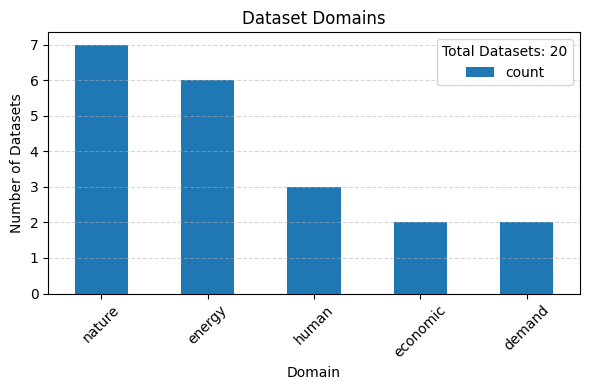

In [20]:
# plot ds_info statistics
plt.figure(figsize=(6, 4))
ds_info['domain'].value_counts().plot(kind='bar')
plt.title('Dataset Domains')
plt.xlabel('Domain')
plt.ylabel('Number of Datasets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
#add total in legend
plt.legend(title='Total Datasets: 20', loc='upper right')
plt.show()  

In [22]:
gran_map = {'QS-OCT': 'quaterly',
    'h': 'hourly',
    'D': 'daily',
    'W-TUE': 'weekly'
}
ds_info['granularity'] = ds_info['granularity'].map(gran_map)
ds_info['granularity'].value_counts()

granularity
hourly      11
daily        7
quaterly     1
weekly       1
Name: count, dtype: int64

In [ ]:
ds_info['granularity'] = pd.Categorical(ds_info['granularity'], categories=['quaterly', 'weekly', 'daily', 'hourly'], ordered=True)
ds_info = ds_info.sort_values(by='granularity')

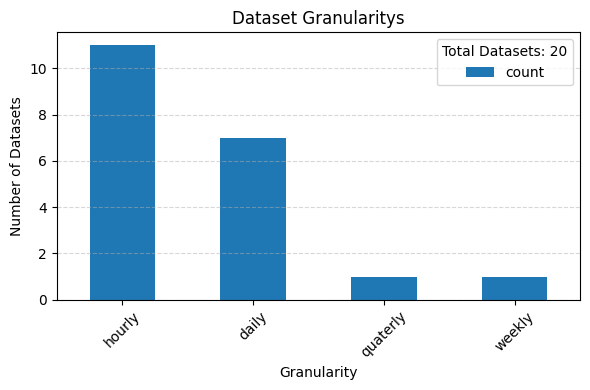

In [28]:
# plot ds_info statistics
plt.figure(figsize=(6, 4))
ds_info['granularity'].value_counts().plot(kind='bar')
plt.title('Dataset Granularitys')
plt.xlabel('Granularity')
plt.ylabel('Number of Datasets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
#add total in legend
plt.legend(title='Total Datasets: 20', loc='upper right')
plt.show()  

In [35]:
new_col_names = {
    'num_ts': 'Time Series',
    'num_targets': 'Targets',
    'num_past_covariates': 'Past Covariates',
    'num_future_covariates': 'Future Covariates',
}
ds_info = ds_info.rename(columns=new_col_names)

<Figure size 2000x1400 with 0 Axes>

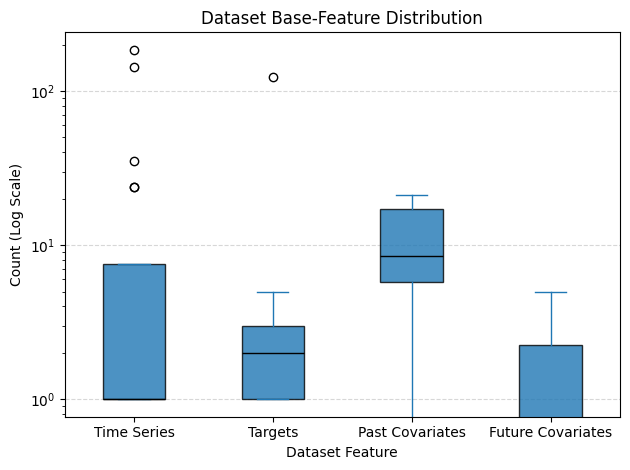

In [ ]:
plt.figure(figsize=(20, 14))

boxplot = ds_info[['Time Series', 'Targets', 'Past Covariates', 'Future Covariates']].plot(
    kind='box',
    vert=True,
    patch_artist=True,
    boxprops=dict(alpha=0.8),
    medianprops=dict(color='black'),
)

# Set custom colors for each box
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
for patch, color in zip(boxplot.artists, colors):
    patch.set_facecolor(color)


plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Dataset Base-Feature Distribution')
plt.ylabel('Count (Log Scale)')
plt.xlabel('Dataset Feature')
plt.yscale('log')


plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [43]:
distances = pd.read_csv('../data/time_series_distances.csv')

In [54]:
distances['distance'].describe()


count    1.112286e+06
mean     3.705988e+03
std      6.981926e+03
min      0.000000e+00
25%      3.704139e+02
50%      1.964246e+03
75%      3.964432e+03
max      1.036620e+05
Name: distance, dtype: float64

In [55]:
distances[(distances['ts_id_1'].isin(ts_ids)) & (distances['ts_id_2'].isin(ts_ids))]['distance'].describe()

count      6786.000000
mean      10963.062261
std       18423.411442
min           4.870969
25%        1748.728266
50%        6910.405422
75%       10237.797545
max      103662.030049
Name: distance, dtype: float64

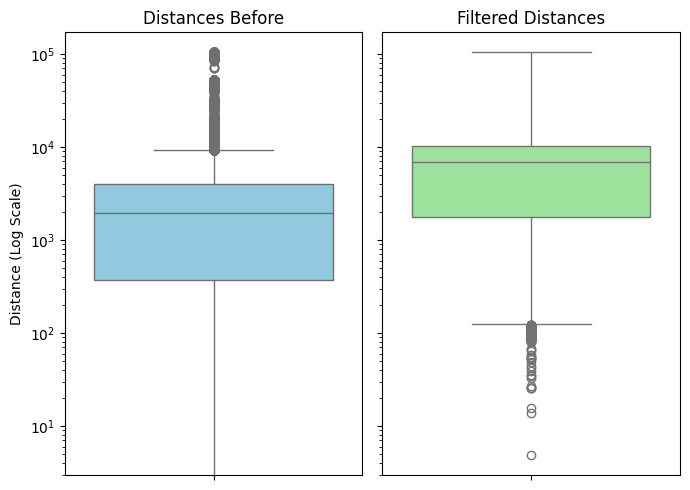

In [53]:
# Create variables for normal and filtered distances using the "distances" DataFrame and the list "ts_ids"
normal_distances = distances['distance']
filtered_distances = distances[(distances['ts_id_1'].isin(ts_ids)) & (distances['ts_id_2'].isin(ts_ids))]['distance']

fig, axes = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

# Boxplot for normal_distances
sns.boxplot(y=normal_distances, ax=axes[0], color='skyblue')
axes[0].set_title('Distances Before')
axes[0].set_ylabel('Distance (Log Scale)')
axes[0].set_yscale('log') # Set y-axis to log scale

# Boxplot for filtered_distances
sns.boxplot(y=filtered_distances, ax=axes[1], color='lightgreen')
axes[1].set_title('Filtered Distances')
# The y-label for the second plot is not strictly necessary when sharing,
# but keeping it for clarity if the user decides to remove sharing later.
axes[1].set_ylabel('Distance (Log Scale)')
axes[1].set_yscale('log') # Set y-axis to log scale

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()
# Display the plot
plt.show()